# CSI4142 Assignment 2
Jonathan Cojita, Lucas Gavura

## Part 1: Validation Checking
Lucas Gavura

In [274]:
#Imports needed libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
from collections import defaultdict

In [275]:
#Import dataset and preview
path = kagglehub.dataset_download(
    "ranaghulamnabi/us-top-50-universities-2026-rankings-and-key-metrics"
)

df = pd.read_csv(f"{path}/US_Top_50_Universities_2026.csv")
df_original = df.copy()
print(df.head())

                               University_Name  National_Rank  Founded_Year  \
0  Massachusetts Institute of Technology (MIT)              1          1861   
1                          Columbia University              2          1754   
2                         Princeton University              3          1746   
3                          Stanford University              4          1891   
4           University of California, Berkeley              5          1868   

  Institution_Type State  Research_Impact_Score  Intl_Student_Ratio  \
0          Private    MA                  100.0                91.6   
1          Private    NY                   95.9                83.7   
2          Private    NJ                   99.0                70.0   
3          Private    CA                   99.5                73.5   
4           Public    CA                   98.9                70.6   

   Employment_Rate  
0             96.2  
1             92.1  
2             94.5  
3             

### 1.1:
**Data Type Errors**

This test verifies the values in the columns match their expected data types, we will ensure that the column for integers doesn't contain any strings or other incompatible data types.


In [276]:
df['National_Rank'] = df['National_Rank'].astype(object)
rows = df.sample(frac=0.06, random_state=1).index
df.loc[rows, 'National_Rank'] = "Error"

In [277]:
type_errors = df[~pd.to_numeric(df['National_Rank'], errors='coerce').notnull()]

print("Number of Data Type Errors:", len(type_errors))
type_errors.head()

Number of Data Type Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
27,University of Southern California (USC),Error,1880,Private,CA,91.5,25.4,89.7
35,Pomona College,Error,1887,Private,CA,34.5,11.8,87.9
40,Georgetown University,Error,1789,Private,DC,78.4,18.9,90.3


In [278]:
original_rows = df_original.loc[type_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(type_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
27,University of Southern California (USC),28,1880,Private,CA,91.5,25.4,89.7
35,Pomona College,36,1887,Private,CA,34.5,11.8,87.9
40,Georgetown University,41,1789,Private,DC,78.4,18.9,90.3



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
27,University of Southern California (USC),Error,1880,Private,CA,91.5,25.4,89.7
35,Pomona College,Error,1887,Private,CA,34.5,11.8,87.9
40,Georgetown University,Error,1789,Private,DC,78.4,18.9,90.3


### 1.2:
**Range Errors**

This test we will verify the range of a numeritical value and ensure it falls within a logical range, so in this test we will ensure the research impact score stays within 0-100.


In [279]:
rows = df.sample(frac=0.06, random_state=2).index
df.loc[rows, 'Research_Impact_Score'] = -10

In [280]:
range_errors = df[(df['Research_Impact_Score'] < 0) | (df['Research_Impact_Score'] > 100)]
print("Number of Range Errors:", len(range_errors))
range_errors

Number of Range Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
28,Wellesley College,29,1870,Private,MA,-10.0,12.5,85.2
36,"University of Maryland, College Park",37,1856,Public,MD,-10.0,18.2,82.1
47,Colgate University,48,1819,Private,NY,-10.0,8.4,88.1


In [281]:
original_rows = df_original.loc[range_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(range_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
28,Wellesley College,29,1870,Private,MA,32.1,12.5,85.2
36,"University of Maryland, College Park",37,1856,Public,MD,86.4,18.2,82.1
47,Colgate University,48,1819,Private,NY,30.2,8.4,88.1



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
28,Wellesley College,29,1870,Private,MA,-10.0,12.5,85.2
36,"University of Maryland, College Park",37,1856,Public,MD,-10.0,18.2,82.1
47,Colgate University,48,1819,Private,NY,-10.0,8.4,88.1


### 1.3:
**Format errors**

This test verifies the strings following specific formats follow them. We will ensure institution type is in the format of public or private.


In [282]:

rows = df.sample(frac=0.06, random_state=3).index
df.loc[rows, 'Institution_Type'] = "priv"

In [283]:
valid_types = ["Public", "Private"]

format_errors = df[
    ~df['Institution_Type'].isin(valid_types)
]

print("Number of Format Errors Detected:", len(format_errors))
display(format_errors.head(3))

Number of Format Errors Detected: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
9,University of Pennsylvania,10,1740,priv,PA,96.1,76.3,94.8
12,University of Chicago,13,1890,priv,IL,96.8,92.8,91.2
39,Brigham Young University,40,1875,priv,UT,45.2,5.1,84.4


In [284]:
original_rows = df_original.loc[format_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(format_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
9,University of Pennsylvania,10,1740,Private,PA,96.1,76.3,94.8
12,University of Chicago,13,1890,Private,IL,96.8,92.8,91.2
39,Brigham Young University,40,1875,Private,UT,45.2,5.1,84.4



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
9,University of Pennsylvania,10,1740,priv,PA,96.1,76.3,94.8
12,University of Chicago,13,1890,priv,IL,96.8,92.8,91.2
39,Brigham Young University,40,1875,priv,UT,45.2,5.1,84.4


### 1.4:
**Consistency Errors**

This test verifies a logical consistency between attributes, a US university cannot be top rated if the emploment rate is very low.


In [285]:
rows = df.sample(frac=0.06, random_state=4).index
df.loc[rows, 'National_Rank'] = 1
df.loc[rows, 'Employment_Rate'] = 10

In [286]:
consistency_errors = df[
    (df['National_Rank'] == 1) & 
    (df['Employment_Rate'].astype(float) < 50)
]

print("Number of Consistency Errors:", len(consistency_errors))
consistency_errors.head()

Number of Consistency Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
6,Williams College,1,1793,Private,MA,45.2,8.5,10.0
11,Rice University,1,1912,Private,TX,85.4,25.1,10.0
48,New York University (NYU),1,1831,Private,NY,94.3,74.1,10.0


In [287]:
original_rows = df_original.loc[consistency_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(consistency_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
6,Williams College,7,1793,Private,MA,45.2,8.5,89.1
11,Rice University,12,1912,Private,TX,85.4,25.1,87.2
48,New York University (NYU),49,1831,Private,NY,94.3,74.1,87.4



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
6,Williams College,1,1793,Private,MA,45.2,8.5,10.0
11,Rice University,1,1912,Private,TX,85.4,25.1,10.0
48,New York University (NYU),1,1831,Private,NY,94.3,74.1,10.0


### 1.5:
**Uniqueness Errors**

This test verifies that rows with unique entities do not have duplicates, as there cannot be two M.I.T's or Stanfords.


In [288]:
rows = df.sample(frac=0.06, random_state=5).index
df.loc[rows, 'University_Name'] = df.loc[rows[0], 'University_Name']

In [289]:
uniqueness_errors = df[df['University_Name'].duplicated()]

print("Number of Uniqueness Errors:", len(uniqueness_errors))
uniqueness_errors.head()

Number of Uniqueness Errors: 2


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
29,Carnegie Mellon University,30,1853,Public,FL,88.4,10.2,84.1
42,Carnegie Mellon University,43,1900,Private,PA,99.0,84.3,93.7


In [290]:
original_rows = df_original.loc[uniqueness_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(uniqueness_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
29,University of Florida,30,1853,Public,FL,88.4,10.2,84.1
42,Carnegie Mellon University,43,1900,Private,PA,99.0,84.3,93.7



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
29,Carnegie Mellon University,30,1853,Public,FL,88.4,10.2,84.1
42,Carnegie Mellon University,43,1900,Private,PA,99.0,84.3,93.7


### 1.6:
**Presence Errors**

This test verifies that all university entries have a name, as you cannot have a nameless university.

In [291]:
rows = df.sample(frac=0.06, random_state=6).index
df.loc[rows, 'University_Name'] = np.nan

In [292]:
presence_errors = df[df['University_Name'].isnull()]

print("Number of Presence Errors:", len(presence_errors))
presence_errors.head()

Number of Presence Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
38,NaN,39,1794,Private,ME,30.1,7.2,86.0
40,NaN,Error,1789,Private,DC,78.4,18.9,90.3
49,NaN,50,1861,Public,WA,97.6,70.1,85.3


In [293]:
original_rows = df_original.loc[presence_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(presence_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
38,Bowdoin College,39,1794,Private,ME,30.1,7.2,86.0
40,Georgetown University,41,1789,Private,DC,78.4,18.9,90.3
49,"University of Washington, Seattle",50,1861,Public,WA,97.6,70.1,85.3



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
38,NaN,39,1794,Private,ME,30.1,7.2,86.0
40,NaN,Error,1789,Private,DC,78.4,18.9,90.3
49,NaN,50,1861,Public,WA,97.6,70.1,85.3


### 1.7:
**Length Errors**

This test verifies that all values match the expected length. Here we are verifying that all State codes are a length of two.


In [294]:
rows = df.sample(frac=0.06, random_state=7).index

df.loc[rows, 'State'] = "California" 

In [295]:
length_errors = df[df['State'].astype(str).str.len() != 2]

print("Number of Length Errors:", len(length_errors))
length_errors.head()

Number of Length Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
13,Cornell University,14,1865,Private,California,95.9,75.7,92.6
15,Northwestern University,16,1851,Private,California,96.9,71.0,90.7
22,Swarthmore College,23,1864,Private,California,40.1,12.1,86.4


In [296]:
original_rows = df_original.loc[length_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(length_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
13,Cornell University,14,1865,Private,NY,95.9,75.7,92.6
15,Northwestern University,16,1851,Private,IL,96.9,71.0,90.7
22,Swarthmore College,23,1864,Private,PA,40.1,12.1,86.4



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
13,Cornell University,14,1865,Private,California,95.9,75.7,92.6
15,Northwestern University,16,1851,Private,California,96.9,71.0,90.7
22,Swarthmore College,23,1864,Private,California,40.1,12.1,86.4


### 1.8:
**Look-up Errors**

This test verifies that all values are part of a predefined list. So here all State codes must belong to a legitimate State.

In [297]:
df_lookup = df_original.copy()

rows = df_lookup.sample(frac=0.06, random_state=8).index
df_lookup.loc[rows, 'State'] = "ZZ"

In [298]:
valid_states = [
  'AL', 'AK', 'AS', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FM', 'FL', 'GA', 'GU', 'HI', 'ID',
  'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MH', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE',
  'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'MP', 'OH', 'OK', 'OR', 'PW', 'PA', 'PR', 'RI', 'SC',
  'SD', 'TN', 'TX', 'UT', 'VT', 'VI', 'VA', 'WA', 'WV', 'WI', 'WY'
]

lookup_errors = df_lookup[~df_lookup['State'].isin(valid_states)]

print("Number of Look-up Errors:", len(lookup_errors))
lookup_errors.head()

Number of Look-up Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
36,"University of Maryland, College Park",37,1856,Public,ZZ,86.4,18.2,82.1
44,Boston University,45,1839,Private,ZZ,82.1,74.7,85.9
49,"University of Washington, Seattle",50,1861,Public,ZZ,97.6,70.1,85.3


In [299]:
original_rows = df_original.loc[lookup_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(lookup_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
36,"University of Maryland, College Park",37,1856,Public,MD,86.4,18.2,82.1
44,Boston University,45,1839,Private,MA,82.1,74.7,85.9
49,"University of Washington, Seattle",50,1861,Public,WA,97.6,70.1,85.3



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
36,"University of Maryland, College Park",37,1856,Public,ZZ,86.4,18.2,82.1
44,Boston University,45,1839,Private,ZZ,82.1,74.7,85.9
49,"University of Washington, Seattle",50,1861,Public,ZZ,97.6,70.1,85.3


## Part 2: Imputation
Jonathan Cojita

In [69]:
#Imports needed libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


In [70]:
#Import dataset and preview
path = kagglehub.dataset_download(
    "yashdev01/spotify-tracks-dataset"
)

df = pd.read_csv(f"{path}/spotify-tracks-dataset.csv")
print(df.head())

   Unnamed: 0.1  Unnamed: 0                track_id                 artists  \
0             0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1             1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2             2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3             3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4             4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       1496

### 2.1:
**Type of Imputation**:
**Description of Imputation**:

**Type of Missing Data Simulated**:
**Attrtibute Affected**:
**How Missing Data is Simulated**:


speechiness - MCAR (Median)
Genre - MAR (Similarity Based)
Popularity - MCAR (Regression)


In [71]:
#Simulate MCAR over genre column
missing_rate = 0.1
n_missing = int(len(df) * missing_rate)
missing_indices = np.random.choice(df.index, n_missing, replace=False)

# Save original values before introducing NaN so we can evaluate imputation later
original_genre_values = df.loc[missing_indices, 'speechiness'].copy()

df.loc[missing_indices, 'speechiness'] = np.nan

#Print missing value row sample (Print track, artist, and genre)
print(df[df['speechiness'].isna()].head()[['track_name', 'artists', 'speechiness']])

               track_name                    artists  speechiness
8                   Lucky  Jason Mraz;Colbie Caillat          NaN
16  ily (i love you baby)       Andrew Foy;Renee Foy          NaN
19             Photograph    Boyce Avenue;Bea Miller          NaN
34           Party of One   Brandi Carlile;Sam Smith          NaN
35           Party of One   Brandi Carlile;Sam Smith          NaN


In [72]:
#Calculate the speachiness mean
mean_speechiness = df['speechiness'].mean()
print(f"Mean speechiness: {mean_speechiness}")

Mean speechiness for imputation: 0.08464758674463937


In [73]:
#Impute missing values with mode
imputed_indices = df[df['speechiness'].isna()].index
df['speechiness'] = df['speechiness'].fillna(mean_speechiness)

#Print the rows that were just imputed to confirm
print(f"Imputed {len(imputed_indices)} rows")
print(df.loc[imputed_indices, ['track_name', 'artists', 'speechiness']].head())

Imputed 11400 rows
               track_name                    artists  speechiness
8                   Lucky  Jason Mraz;Colbie Caillat     0.084648
16  ily (i love you baby)       Andrew Foy;Renee Foy     0.084648
19             Photograph    Boyce Avenue;Bea Miller     0.084648
34           Party of One   Brandi Carlile;Sam Smith     0.084648
35           Party of One   Brandi Carlile;Sam Smith     0.084648


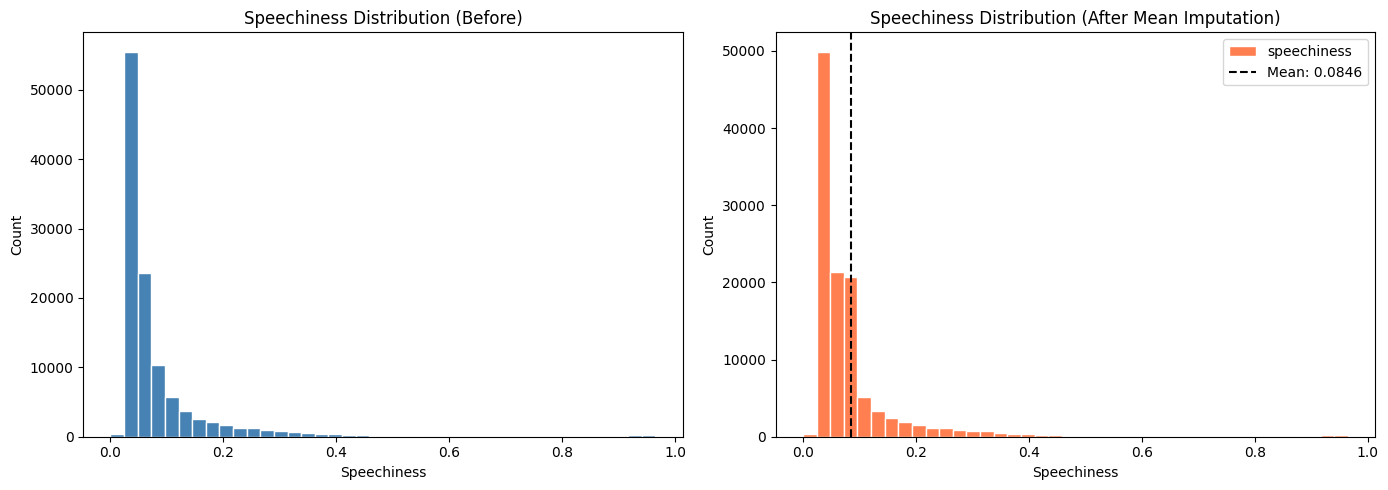

            Before     After     Delta
Mean      0.084652  0.084648 -0.000005
Median    0.048900  0.053200  0.004300
Std Dev   0.105732  0.100209 -0.005524
Skewness  4.647516  4.901815  0.254299


In [74]:
#Plot speechiness distribution before vs after imputation (full dataset)

# Reconstruct full "before" distribution: original values for imputed rows + untouched rows
before_full = pd.concat([
    original_genre_values,
    df.loc[~df.index.isin(missing_indices), 'speechiness']
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_full.plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Speechiness Distribution (Before)')
axes[0].set_xlabel('Speechiness')
axes[0].set_ylabel('Count')

df['speechiness'].plot(kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].axvline(mean_speechiness, color='black', linestyle='--', label=f'Mean: {mean_speechiness:.4f}')
axes[1].set_title('Speechiness Distribution (After Mean Imputation)')
axes[1].set_xlabel('Speechiness')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

#Compare distribution statistics before and after imputation
stats = pd.DataFrame({
    'Before': [
        before_full.mean(),
        before_full.median(),
        before_full.std(),
        before_full.skew(),
    ],
    'After': [
        df['speechiness'].mean(),
        df['speechiness'].median(),
        df['speechiness'].std(),
        df['speechiness'].skew(),
    ]
}, index=['Mean', 'Median', 'Std Dev', 'Skewness'])

stats['Delta'] = stats['After'] - stats['Before']
print(stats.round(6))

## 2.2

**Type of Imputation**: Similarity-based Imputation

**Description of Imputation**: Trained a KNN model from the Scikit-learn library to predict genres (missing attribute) based on it 5 closest neighbors (determined by all other columns).

**Type of Missing Data Simulated**: MAR

**Attribute Affected**: track_genre

**How Missing Data is Simulated**: Songs with lower popularity are assigned a higher probability of having a missing genre, creating a dependency between missingness and an observed variable (popularity).

In [75]:
# Simulate MAR over track_genre column
# Songs with lower popularity have a higher probability of missing genre
missing_rate = 0.1
n_missing = int(len(df) * missing_rate)

# Weight is inversely proportional to popularity: low popularity -> high missingness probability
weights = (df['popularity'].max() - df['popularity'] + 1).astype(float)
prob = weights / weights.sum()

missing_indices_genre = np.random.choice(df.index, size=n_missing, replace=False, p=prob)

# Save original values before introducing NaN so we can evaluate imputation later
original_genre_values_mar = df.loc[missing_indices_genre, 'track_genre'].copy()

df.loc[missing_indices_genre, 'track_genre'] = np.nan

# Verify MAR mechanism: missing rows should have a lower mean popularity than the full dataset
print(f"Mean popularity (all rows):           {df['popularity'].mean():.2f}")
print(f"Mean popularity (missing genre rows): {df.loc[missing_indices_genre, 'popularity'].mean():.2f}")
print()
print(df[df['track_genre'].isna()].head()[['track_name', 'artists', 'popularity', 'track_genre']])

Mean popularity (all rows):           33.24
Mean popularity (missing genre rows): 25.94

                                           track_name               artists  \
16                              ily (i love you baby)  Andrew Foy;Renee Foy   
24                                           Unlonely            Jason Mraz   
25                                         Bella Luna            Jason Mraz   
29                                  Winter Wonderland            Jason Mraz   
44  Speak Your Mind (From the Netflix Series "We T...        Brandi Carlile   

    popularity track_genre  
16          56         NaN  
24           0         NaN  
25           1         NaN  
29           0         NaN  
44           0         NaN  


In [76]:
# Use numeric audio features to measure similarity between songs
feature_cols_knn = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms', 'explicit', 'mode', 'time_signature'
]

# Split into rows with known genre (training) and missing genre (to impute)
df_genre_known = df[df['track_genre'].notna()]
df_genre_missing = df[df['track_genre'].isna()]

X_train_knn = df_genre_known[feature_cols_knn]
y_train_knn = df_genre_known['track_genre']
X_pred_knn = df_genre_missing[feature_cols_knn]

# Train KNN classifier — each missing song is assigned the majority genre of its 5 nearest neighbours
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train_knn)

# Impute missing genre values
predicted_genres = knn.predict(X_pred_knn)
df.loc[df['track_genre'].isna(), 'track_genre'] = predicted_genres

print(f"Imputed {len(df_genre_missing)} rows")
print(df.loc[df_genre_missing.index[:5], ['track_name', 'artists', 'popularity', 'track_genre']])

Imputed 11400 rows
                                           track_name               artists  \
16                              ily (i love you baby)  Andrew Foy;Renee Foy   
24                                           Unlonely            Jason Mraz   
25                                         Bella Luna            Jason Mraz   
29                                  Winter Wonderland            Jason Mraz   
44  Speak Your Mind (From the Netflix Series "We T...        Brandi Carlile   

    popularity  track_genre  
16          56     children  
24           0        anime  
25           1  death-metal  
29           0     acoustic  
44           0      dubstep  


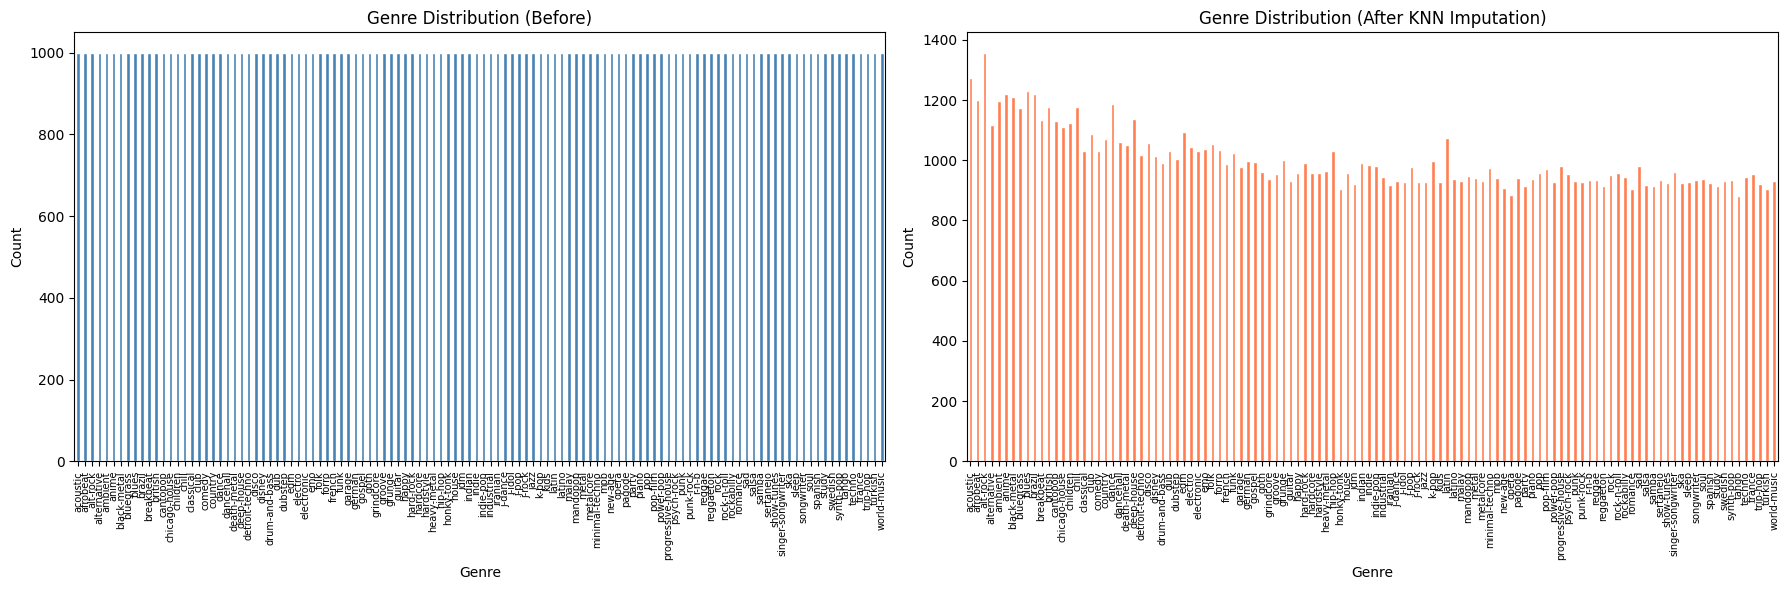

             Before  After  Delta
track_genre                      
acoustic       1000   1273    273
afrobeat       1000   1199    199
alt-rock       1000   1357    357
alternative    1000   1117    117
ambient        1000   1197    197
...             ...    ...    ...
techno         1000    943    -57
trance         1000    955    -45
trip-hop       1000    920    -80
turkish        1000    906    -94
world-music    1000    932    -68

[114 rows x 3 columns]
Accuracy: 0.0846

                   precision    recall  f1-score   support

         acoustic       0.03      0.12      0.05        81
         afrobeat       0.05      0.13      0.07       118
         alt-rock       0.04      0.19      0.06        88
      alternative       0.13      0.24      0.17       129
          ambient       0.03      0.08      0.04        83
            anime       0.02      0.07      0.03        87
      black-metal       0.02      0.06      0.03       114
        bluegrass       0.01      0.04     

In [77]:
# Plot genre distribution before vs after imputation
# Reconstruct full "before" distribution: original values for imputed rows + untouched rows
before_full = pd.concat([
    original_genre_values_mar,
    df.loc[~df.index.isin(missing_indices_genre), 'track_genre']
])

before_counts = before_full.value_counts().sort_index()
after_counts = df['track_genre'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

before_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Genre Distribution (Before)')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

after_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Genre Distribution (After KNN Imputation)')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.show()

# Compare counts before and after
stats = pd.DataFrame({
    'Before': before_counts,
    'After': after_counts,
}).fillna(0).astype(int)
stats['Delta'] = stats['After'] - stats['Before']
print(stats)

# Evaluate KNN imputation against the original genre values that were hidden
y_true = original_genre_values_mar
y_pred = df.loc[missing_indices_genre, 'track_genre']  # read back from df using the exact indices we masked

print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print()
print(classification_report(y_true, y_pred))

## 2.3

**Type of Imputation**: Regression Imputation

**Description of Imputation**: Trained a RandomForrestRegressor using Scikit-learn to predict populatirity (attribute with missing data) using all other attributes as features.

**Type of Missing Data Simulated**: MCAR

**Attrtibute Affected**: Popularity (A continious variable from 0 - 100 representing how popular the song is).

**How Missing Data is Simulated**: We take a defined percentage of the dataset and at random, set that number of rows to have a null popularity.


In [78]:
#Simulate MCAR over popularity column
missing_rate = 0.1
n_missing = int(len(df) * missing_rate)
missing_indices = np.random.choice(df.index, n_missing, replace=False)

# Save original values before introducing NaN so we can evaluate imputation later
original_genre_values = df.loc[missing_indices, 'popularity'].copy()

df.loc[missing_indices, 'popularity'] = np.nan

#Print missing value row sample (Print track, artist, and genre)
print(df[df['popularity'].isna()].head()[['track_name', 'artists', 'popularity']])

                           track_name                  artists  popularity
15   Falling in Love at a Coffee Shop              Landon Pigg         NaN
62                     And I Love Her              Kurt Cobain         NaN
63                      We Can't Stop  Boyce Avenue;Bea Miller         NaN
67                She Used To Be Mine           Sara Bareilles         NaN
68  In My Veins - Feat. Erin Mccarley             Andrew Belle         NaN


In [79]:
#Train a regression model to predict missing popularity

feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms', 'explicit', 'mode', 'time_signature'
]

#Split df into rows where popularity is known vs missing
df_known = df[df['popularity'].notna()]
df_missing = df[df['popularity'].isna()]

#Split known rows into train/test to evaluate model performance
X = df_known[feature_cols]
y = df_known['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train model on training portion of known rows
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [80]:
#Predict popularity for missing rows usingthe trained model
X_pred = df_missing[feature_cols]
predicted = model.predict(X_pred)

#Impute predictions
df.loc[df['popularity'].isna(), 'popularity'] = predicted

print(f"Imputed {len(df_missing)} rows")
print(df.loc[df_missing.index[:5], ['track_name', 'artists', 'popularity']])

Imputed 11400 rows
                           track_name                  artists  popularity
15   Falling in Love at a Coffee Shop              Landon Pigg   36.031053
62                     And I Love Her              Kurt Cobain   28.100000
63                      We Can't Stop  Boyce Avenue;Bea Miller   48.211429
67                She Used To Be Mine           Sara Bareilles   42.440000
68  In My Veins - Feat. Erin Mccarley             Andrew Belle   47.950000


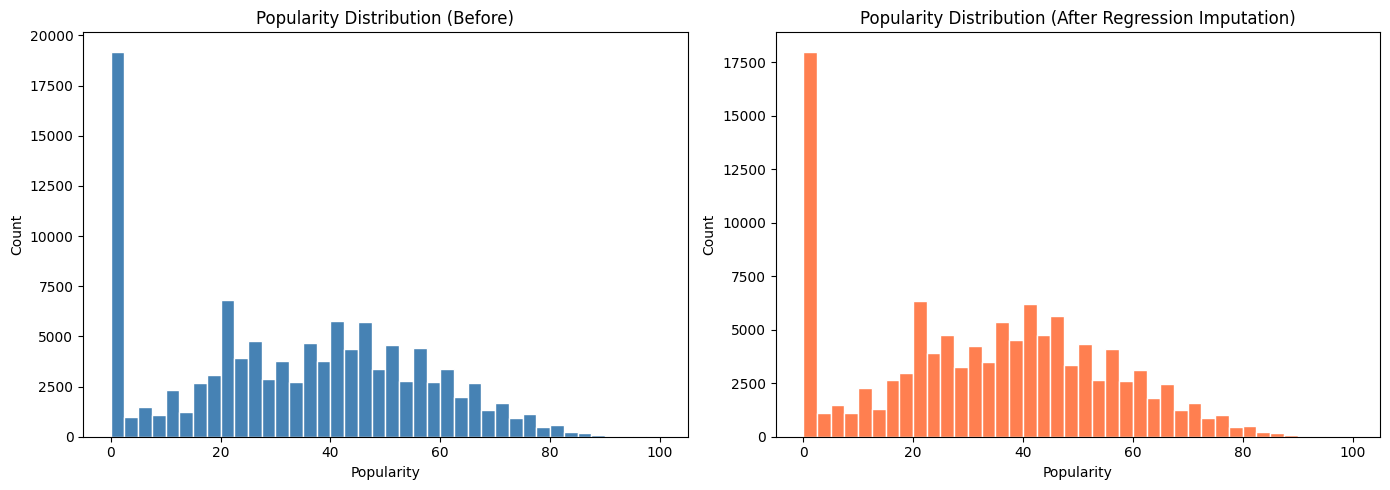

             Before      After     Delta
Mean      33.238535  33.212640 -0.025895
Median    35.000000  35.000000  0.000000
Std Dev   22.305078  21.682035 -0.623043
Skewness   0.046403   0.035247 -0.011155
Test MAE:  11.1254
Test RMSE: 15.4989


In [81]:
#Quantitative evaluation
#Reconstruct full "before" distribution: original values for imputed rows + untouched rows
before_full = pd.concat([
    original_genre_values,
    df.loc[~df.index.isin(missing_indices), 'popularity']
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_full.plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Popularity Distribution (Before)')
axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Count')

df['popularity'].plot(kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Popularity Distribution (After Regression Imputation)')
axes[1].set_xlabel('Popularity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

#Compare distribution values before and after imputation
stats = pd.DataFrame({
    'Before': [
        before_full.mean(),
        before_full.median(),
        before_full.std(),
        before_full.skew(),
    ],
    'After': [
        df['popularity'].mean(),
        df['popularity'].median(),
        df['popularity'].std(),
        df['popularity'].skew(),
    ]
}, index=['Mean', 'Median', 'Std Dev', 'Skewness'])

stats['Delta'] = stats['After'] - stats['Before']
print(stats.round(6))

#Model performance evalutaion
y_pred_test = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# References
- https://seaborn.pydata.org/
- https://github.com/lemay-ai/CEG4195-SEG4180/tree/main 
    - (Course Github for SEG4180 used for model training reference)
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html